In this work, we will use the KMeans Clustering algorithm to cluster universities into to two groups: "Private" and "Public"
Please note that under normal circumstances we employ the KMeans algorithm in situations where class labels are not available i.e. for unsupervised learning, hence in this example we will ignore the given class labels and go ahead to perform our clustering task.

### The Data
Our data has 777 observations and 18 variables, as follows:
- Private: factor with levels No and Yes indicating private or public university
- Apps: # of applications received
- Accept: # of applications accepted
- Enroll: # of new students enrolled
- Top10perc: % of new students from top 10% of H.S. class
- Top25perc: % of new students from top 25% of H.S. class
- F.Undergrad: # of full-time undergraduates
- P.Undergrad: # of part-time undergraduates
- Outstate: Out-of-state tuition
- Room.Board: Room and boarding costs
- Books: Estimated books cost
- Personal: Estimated personal spending cost
- PhD: % of faculty with Ph.Ds
- Terminal: % of faculty with terminal degree
- S.F.Ratio: Student/faculty ratio
- perc.alumni: % of alumni who donate
- Expend: Instructional expenditure per student
- Grad.Rate: Graduation rate


- Import the relevant libraries needed for data analysis

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [2]:
df = pd.read_csv('College_Data',index_col=0)

In [5]:
# view the top 10 rows of the data
df.head(10)

,Private,Apps,Accept,Enroll,Top10perc,Top25perc,F.Undergrad,P.Undergrad,Outstate,Room.Board,Books,Personal,PhD,Terminal,S.F.Ratio,perc.alumni,Expend,Grad.Rate
Abilene Christian University,Yes,1660,1232,721,23,52,2885,537,7440,3300,450,2200,70,78,18.1,12,7041,60
Adelphi University,Yes,2186,1924,512,16,29,2683,1227,12280,6450,750,1500,29,30,12.2,16,10527,56
Adrian College,Yes,1428,1097,336,22,50,1036,99,11250,3750,400,1165,53,66,12.9,30,8735,54
Agnes Scott College,Yes,417,349,137,60,89,510,63,12960,5450,450,875,92,97,7.7,37,19016,59
Alaska Pacific University,Yes,193,146,55,16,44,249,869,7560,4120,800,1500,76,72,11.9,2,10922,15
Albertson College,Yes,587,479,158,38,62,678,41,13500,3335,500,675,67,73,9.4,11,9727,55
Albertus Magnus College,Yes,353,340,103,17,45,416,230,13290,5720,500,1500,90,93,11.5,26,8861,63
Albion College,Yes,1899,1720,489,37,68,1594,32,13868,4826,450,850,89,100,13.7,37,11487,73
Albright College,Yes,1038,839,227,30,63,973,306,15595,4400,300,500,79,84,11.3,23,11644,80
Alderson-Broaddus College,Yes,582,498,172,21,44,799,78,10468,3380,660,1800,40,41,11.5,15,8991,52


- Run the info() and describe() methods on the data

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 777 entries, Abilene Christian University to York College of Pennsylvania
Data columns (total 18 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Private      777 non-null    object 
 1   Apps         777 non-null    int64  
 2   Accept       777 non-null    int64  
 3   Enroll       777 non-null    int64  
 4   Top10perc    777 non-null    int64  
 5   Top25perc    777 non-null    int64  
 6   F.Undergrad  777 non-null    int64  
 7   P.Undergrad  777 non-null    int64  
 8   Outstate     777 non-null    int64  
 9   Room.Board   777 non-null    int64  
 10  Books        777 non-null    int64  
 11  Personal     777 non-null    int64  
 12  PhD          777 non-null    int64  
 13  Terminal     777 non-null    int64  
 14  S.F.Ratio    777 non-null    float64
 15  perc.alumni  777 non-null    int64  
 16  Expend       777 non-null    int64  
 17  Grad.Rate    777 non-null    int64  
dtypes: 

In [8]:
df.describe().transpose()

,count,mean,std,min,25%,50%,75%,max
Apps,777.0,3001.638353,3870.201484,81.0,776.0,1558.0,3624.0,48094.0
Accept,777.0,2018.804376,2451.113971,72.0,604.0,1110.0,2424.0,26330.0
Enroll,777.0,779.972973,929.176190,35.0,242.0,434.0,902.0,6392.0
Top10perc,777.0,27.558559,17.640364,1.0,15.0,23.0,35.0,96.0
Top25perc,777.0,55.796654,19.804778,9.0,41.0,54.0,69.0,100.0
F.Undergrad,777.0,3699.907336,4850.420531,139.0,992.0,1707.0,4005.0,31643.0
P.Undergrad,777.0,855.298584,1522.431887,1.0,95.0,353.0,967.0,21836.0
Outstate,777.0,10440.669241,4023.016484,2340.0,7320.0,9990.0,12925.0,21700.0
Room.Board,777.0,4357.526384,1096.696416,1780.0,3597.0,4200.0,5050.0,8124.0
Books,777.0,549.380952,165.105360,96.0,470.0,500.0,600.0,2340.0


##### EDA

- Let us create some visualizations:

- Scatterplot of Grad.Rate versus Room.Board where the points are colored by the Private column

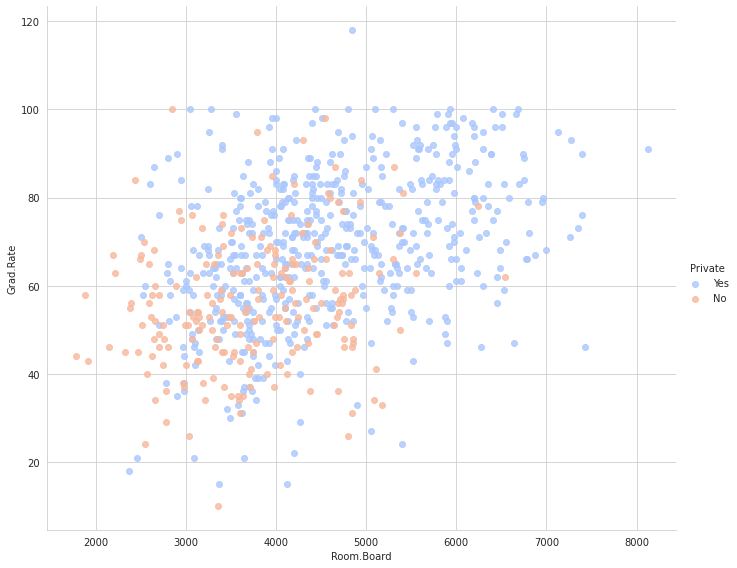

In [10]:
sns.set_style('whitegrid')
sns.lmplot(x='Room.Board', y='Grad.Rate',data=df, hue='Private',
           palette='coolwarm',height=8,aspect=1.2,fit_reg=False)

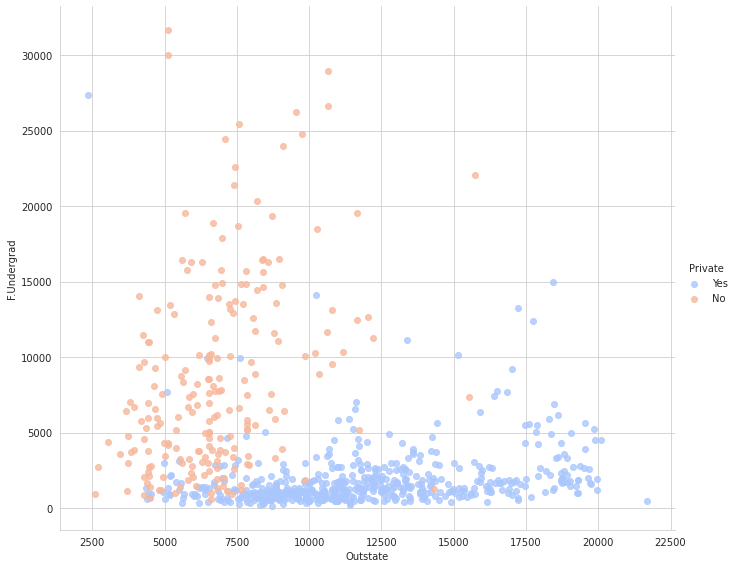

In [11]:
# Similarly:
sns.set_style('whitegrid')
sns.lmplot(x='Outstate', y='F.Undergrad',data=df, hue='Private',
           palette='coolwarm',height=8,aspect=1.2,fit_reg=False)

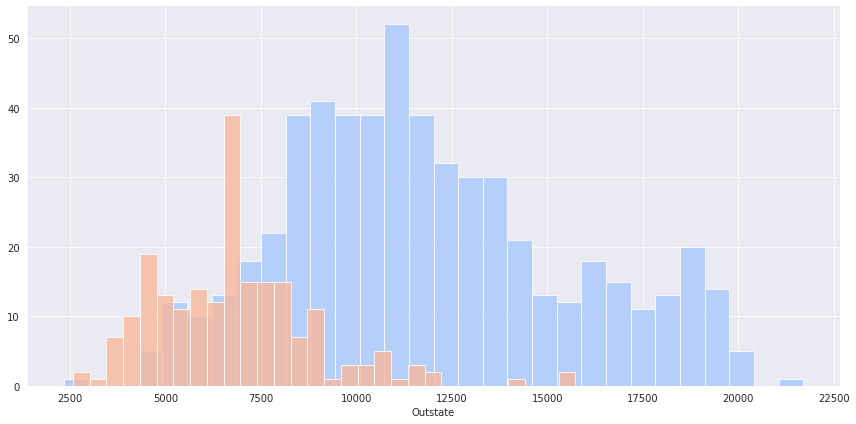

In [21]:
# Visualizing the overall out of state students preference for either private or public universities
sns.set_style('darkgrid')
g = sns.FacetGrid(df, hue="Private", palette='coolwarm', height=6, aspect=2)
g = g.map(plt.hist,'Outstate',bins=30,alpha=0.8)

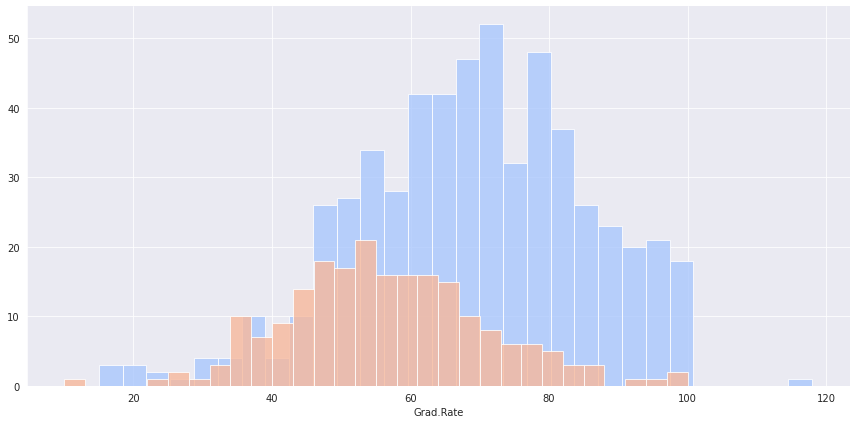

In [22]:
sns.set_style('darkgrid')
g = sns.FacetGrid(df,hue="Private",palette='coolwarm',height=6,aspect=2)
g = g.map(plt.hist,'Grad.Rate',bins=30,alpha=0.8)

In [23]:
# Let's figure out the Private university with Graduation Rate greater than 100%
df[df['Grad.Rate'] > 100]

,Private,Apps,Accept,Enroll,Top10perc,Top25perc,F.Undergrad,P.Undergrad,Outstate,Room.Board,Books,Personal,PhD,Terminal,S.F.Ratio,perc.alumni,Expend,Grad.Rate
Cazenovia College,Yes,3847,3433,527,9,35,1010,12,9384,4840,600,500,22,47,14.3,20,7697,118


- For modeling purposes, you might want to cap this value to 100% for clarity.

In [24]:
# Note: You might get a warning, which is fine in this case.
df['Grad.Rate']['Cazenovia College'] = 100

/home/rich/anaconda3/lib/python3.7/site-packages/ipykernel_launcher.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  """Entry point for launching an IPython kernel.


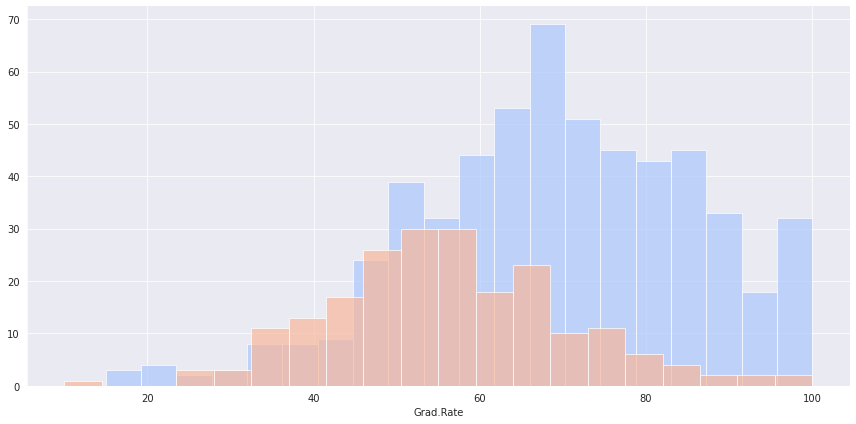

In [26]:
# Let us visualize again to see what we just capped!
sns.set_style('darkgrid')
g = sns.FacetGrid(df,hue="Private",palette='coolwarm',height=6,aspect=2)
g = g.map(plt.hist,'Grad.Rate',bins=20,alpha=0.7)

#### K Means Cluster Creation

In [27]:
# Importing KMeans from SciKit Learn; and then create an instance of a K Means model with 2 clusters
from sklearn.cluster import KMeans
kmeans = KMeans(n_clusters=2)

In [28]:
# we fit the model without the class label 'Private'
kmeans.fit(df.drop('Private',axis=1))

KMeans(algorithm='auto', copy_x=True, init='k-means++', max_iter=300,
       n_clusters=2, n_init=10, n_jobs=None, precompute_distances='auto',
       random_state=None, tol=0.0001, verbose=0)

In [30]:
# List/View the cluster center vectors
kmeans.cluster_centers_

array([[1.81323468e+03, 1.28716592e+03, 4.91044843e+02, 2.53094170e+01,
        5.34708520e+01, 2.18854858e+03, 5.95458894e+02, 1.03957085e+04,
        4.31136472e+03, 5.41982063e+02, 1.28033632e+03, 7.04424514e+01,
        7.78251121e+01, 1.40997010e+01, 2.31748879e+01, 8.93204634e+03,
        6.50926756e+01],
       [1.03631389e+04, 6.55089815e+03, 2.56972222e+03, 4.14907407e+01,
        7.02037037e+01, 1.30619352e+04, 2.46486111e+03, 1.07191759e+04,
        4.64347222e+03, 5.95212963e+02, 1.71420370e+03, 8.63981481e+01,
        9.13333333e+01, 1.40277778e+01, 2.00740741e+01, 1.41705000e+04,
        6.75925926e+01]])

#### Form of Evaluation:
- We will use the known labels to help us evaluate the model by converting the class labels to numeric values using a user-define function as follows

In [31]:
def converter(cluster):
    if cluster=='Yes':
        return 1
    else:
        return 0

In [32]:
# With the function, we add a new column to df called 'Cluster', with 1 for a Private school, and 0 for a Public school
df['Cluster'] = df['Private'].apply(converter)

In [33]:
df.head()

,Private,Apps,Accept,Enroll,Top10perc,Top25perc,F.Undergrad,P.Undergrad,Outstate,Room.Board,Books,Personal,PhD,Terminal,S.F.Ratio,perc.alumni,Expend,Grad.Rate,Cluster
Abilene Christian University,Yes,1660,1232,721,23,52,2885,537,7440,3300,450,2200,70,78,18.1,12,7041,60,1
Adelphi University,Yes,2186,1924,512,16,29,2683,1227,12280,6450,750,1500,29,30,12.2,16,10527,56,1
Adrian College,Yes,1428,1097,336,22,50,1036,99,11250,3750,400,1165,53,66,12.9,30,8735,54,1
Agnes Scott College,Yes,417,349,137,60,89,510,63,12960,5450,450,875,92,97,7.7,37,19016,59,1
Alaska Pacific University,Yes,193,146,55,16,44,249,869,7560,4120,800,1500,76,72,11.9,2,10922,15,1


- Now, we can create a confusion matrix and classification report to see how well the Kmeans clustering worked without the use of any class labels

In [34]:
from sklearn.metrics import confusion_matrix,classification_report
print(confusion_matrix(df['Cluster'],kmeans.labels_))
print(classification_report(df['Cluster'],kmeans.labels_))

[[138  74]
 [531  34]]
              precision    recall  f1-score   support

           0       0.21      0.65      0.31       212
           1       0.31      0.06      0.10       565

    accuracy                           0.22       777
   macro avg       0.26      0.36      0.21       777
weighted avg       0.29      0.22      0.16       777



#### The overall performance is not great, but this is only for illustration purpose - the algorithm is purely using the features to cluster the universities into 2 distinct groups! The purpose is for you to see how K Means is useful for clustering un-labeled data! You can also play with different number of clusters for your modeling pleasure!